# Partitionnez vos données - Le Bag of Words

## 1. Préliminaires

### 1.1 Contexte 
Ce TP est en lien avec l'activité [Partitionnez vos données](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees/5345241-tp-partitionnez-vos-donnees), de la partie 3 du cours  [Réalisez une analyse exploratoire de données](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees).

### 1.2 Imports

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from scipy.cluster.hierarchy import linkage,dendrogram,fcluster

### 1.3 Chargement des données

In [3]:
# Chemin du repertoire data
data_dir = './data/'

# Chargement des données de bag of words
data = pd.read_csv(data_dir+'bag_of_words.csv')

# Affichage des 5 premières lignes
data.head()

,titre,aaaa,abandonner,abattement,abbr,abc,abondement,abonnement,abonner,abonnés,...,évoqué,évoquées,évoqués,évènement,évènements,événement,événements,êtres,œil,œuvre
0,Concevez des architectures Big Data,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.000469,0.000000,0.000000,0.000000
1,Apprenez à coder avec JavaScript,0.000000,0.0,0.0,0.0,0.000499,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0001,0.0,0.000000,0.000000,0.000000,0.000000
2,Concevez votre site web avec PHP et MySQL,0.000524,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.000000,0.000000,0.000087,0.000000
3,Réussir sa campagne d'e-mailing avec MailChimp,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.020408,0.020408,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.000000,0.000000,0.000000,0.000000
4,Utilisez des modèles supervisés non linéaires,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.000000,0.000325,0.000000,0.000651


In [4]:
# Affichage des dimensions de data
data.shape

(105, 9344)

In [5]:
# Chargement des données sur les cours
courses_info = pd.read_csv(data_dir + "courses_info.csv")

# Affichage des 5 premières lignes
courses_info.head()

,title,charge-e-de-gestion-des-ressources-humaines,manager-rh,gestionnaire-de-paie,data-architect,developpeur-se-dapplication-python,developpeur-web-junior,community-manager,responsable-marketing-operationnel,developpeur-se-d-application-php-symfony,data-scientist,expert-e-en-strategie-marketing-et-communication,data-analyst,theme
0,Apprenez à gérer les conflits,True,True,True,False,False,False,False,False,False,False,False,False,RH
1,Réalisez des calculs distribués sur des donnée...,False,False,False,True,False,False,False,False,False,False,False,False,data
2,Managez une équipe au quotidien,False,True,False,False,False,False,False,False,False,False,False,False,RH
3,Gérez votre code avec Git et GitHub,False,False,False,False,True,True,False,False,False,False,False,False,dev
4,Lancez une campagne de publicité avec Google A...,False,False,False,False,False,False,True,True,False,False,False,False,marketing


In [6]:
courses_info.shape

(112, 14)

## 2 Preparation des données

### 2.1 Merge
On va fusionner les deux dataframes dans le dataframe data

In [7]:
# Choix des colonnes de courses_info
cols=["title","theme"]

# Enregistrement dans un dataframe temporaire
temp = courses_info[cols]
temp.head()

,title,theme
0,Apprenez à gérer les conflits,RH
1,Réalisez des calculs distribués sur des donnée...,data
2,Managez une équipe au quotidien,RH
3,Gérez votre code avec Git et GitHub,dev
4,Lancez une campagne de publicité avec Google A...,marketing


In [10]:
# faisons le merge en rajoutant indicator à True pour savoir dans quel df la clé est manquante
df = data.merge(data,temp,left_on='titre',right_on='title',indicator=True)

# Affichage d'un extrait
df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13156\3191080688.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = data.merge(temp,left_on='titre',right_on='title',indicator=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13156\3191080688.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = data.merge(temp,left_on='titre',right_on='title',indicator=True)


,titre,aaaa,abandonner,abattement,abbr,abc,abondement,abonnement,abonner,abonnés,...,évènement,évènements,événement,événements,êtres,œil,œuvre,title_y,theme_y,_merge
0,Concevez des architectures Big Data,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0000,0.0,0.000469,0.000000,0.000000,0.000000,Concevez des architectures Big Data,data,both
1,Apprenez à coder avec JavaScript,0.000000,0.0,0.0,0.0,0.000499,0.0,0.0,0.000000,0.000000,...,0.0,0.0001,0.0,0.000000,0.000000,0.000000,0.000000,Apprenez à coder avec JavaScript,dev,both
2,Concevez votre site web avec PHP et MySQL,0.000524,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0000,0.0,0.000000,0.000000,0.000087,0.000000,Concevez votre site web avec PHP et MySQL,dev,both
3,Réussir sa campagne d'e-mailing avec MailChimp,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.020408,0.020408,...,0.0,0.0000,0.0,0.000000,0.000000,0.000000,0.000000,Réussir sa campagne d'e-mailing avec MailChimp,marketing,both
4,Utilisez des modèles supervisés non linéaires,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0000,0.0,0.000000,0.000325,0.000000,0.000651,Utilisez des modèles supervisés non linéaires,data,both


In [17]:
# Verifions que le merge est bon
df['_merge'].value_counts()
# Comme ça ne contient que des both , c'est bon

_merge
both          105
left_only       0
right_only      0
Name: count, dtype: int64

### 2.2 Séparation des données
On souhaite obtenir : 
- X : matrice des mots
- themes : les thèmes
- names : les noms 

In [23]:
themes = df['theme_y'].values
themes[:5]

<StringArray>
['data', 'dev', 'dev', 'marketing', 'data']
Length: 5, dtype: str

In [24]:
names = df['titre'].values
names[:]

<StringArray>
[                           'Concevez des architectures Big Data',
                               'Apprenez à coder avec JavaScript',
                      'Concevez votre site web avec PHP et MySQL',
                 'Réussir sa campagne d'e-mailing avec MailChimp',
                  'Utilisez des modèles supervisés non linéaires',
                                 'Animez une communauté Facebook',
                     'Classez et segmentez des données visuelles',
                   'Gérez votre projet informatique facilement !',
                                          'Créez votre Data Lake',
                    'Découvrez le fonctionnement des algorithmes',
 ...
                   'Maîtrisez l'univers des cotisations sociales',
                        'Améliorez l'impact de vos présentations',
                                 'Initiez-vous à la comptabilité',
                                'Elaborez un plan de recrutement',
      'Le commerce omnicanal pour transform

In [25]:
# choix des colonnes à supprimer de df pour obtenir X
cols=["titre","theme_y","title_y","_merge"]

# Matrice
X = df.drop(columns=cols).values
X[:10]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.23788739e-04, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 8.72981231e-05, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.94204178e-04, 0.00000000e+00, 8.82612533e-04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]], shape=(10, 9343))

### 2.3 Standarisation

In [26]:
# Instanciation du scaler
scaler = StandardScaler()

# Entrainement et transformation sur X
X_scaled = scaler.fit_transform(X)

# Affichage d'un extrait de X_scaled
X_scaled[:5]

array([[-0.15710774, -0.26729689, -0.16964264, ..., -0.32346245,
        -0.32270297, -0.37914478],
       [-0.15710774, -0.26729689, -0.16964264, ..., -0.32346245,
        -0.32270297, -0.37914478],
       [ 8.02916858, -0.26729689, -0.16964264, ..., -0.32346245,
        -0.01580055, -0.37914478],
       [-0.15710774, -0.26729689, -0.16964264, ..., -0.32346245,
        -0.32270297, -0.37914478],
       [-0.15710774, -0.26729689, -0.16964264, ...,  3.3812466 ,
        -0.32270297,  0.34530247]], shape=(5, 9343))

In [30]:
# Verification de la standarisation des données
pd.DataFrame(X_scaled).describe().round(2).loc[["std", "mean"]]

,0,1,2,3,4,5,6,7,8,9,...,9333,9334,9335,9336,9337,9338,9339,9340,9341,9342
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mean,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,...,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0


## 3 Clustering

### 3.1 Linkage

In [31]:
# Calcul des distances en utilisant ward
Z = linkage(X_scaled,method="ward")
Z[:10]

array([[  5.        ,  15.        ,  67.08388595,   2.        ],
       [  3.        , 105.        ,  74.40219418,   3.        ],
       [ 82.        , 106.        ,  79.01447844,   4.        ],
       [ 37.        ,  80.        ,  98.91101721,   2.        ],
       [ 34.        ,  98.        , 100.64735993,   2.        ],
       [ 63.        , 101.        , 101.61942786,   2.        ],
       [ 69.        , 107.        , 103.29833521,   5.        ],
       [ 25.        ,  66.        , 103.65713341,   2.        ],
       [ 50.        , 103.        , 106.02937382,   2.        ],
       [ 22.        ,  32.        , 106.6204984 ,   2.        ]])

### 3.2 Dendrogramme

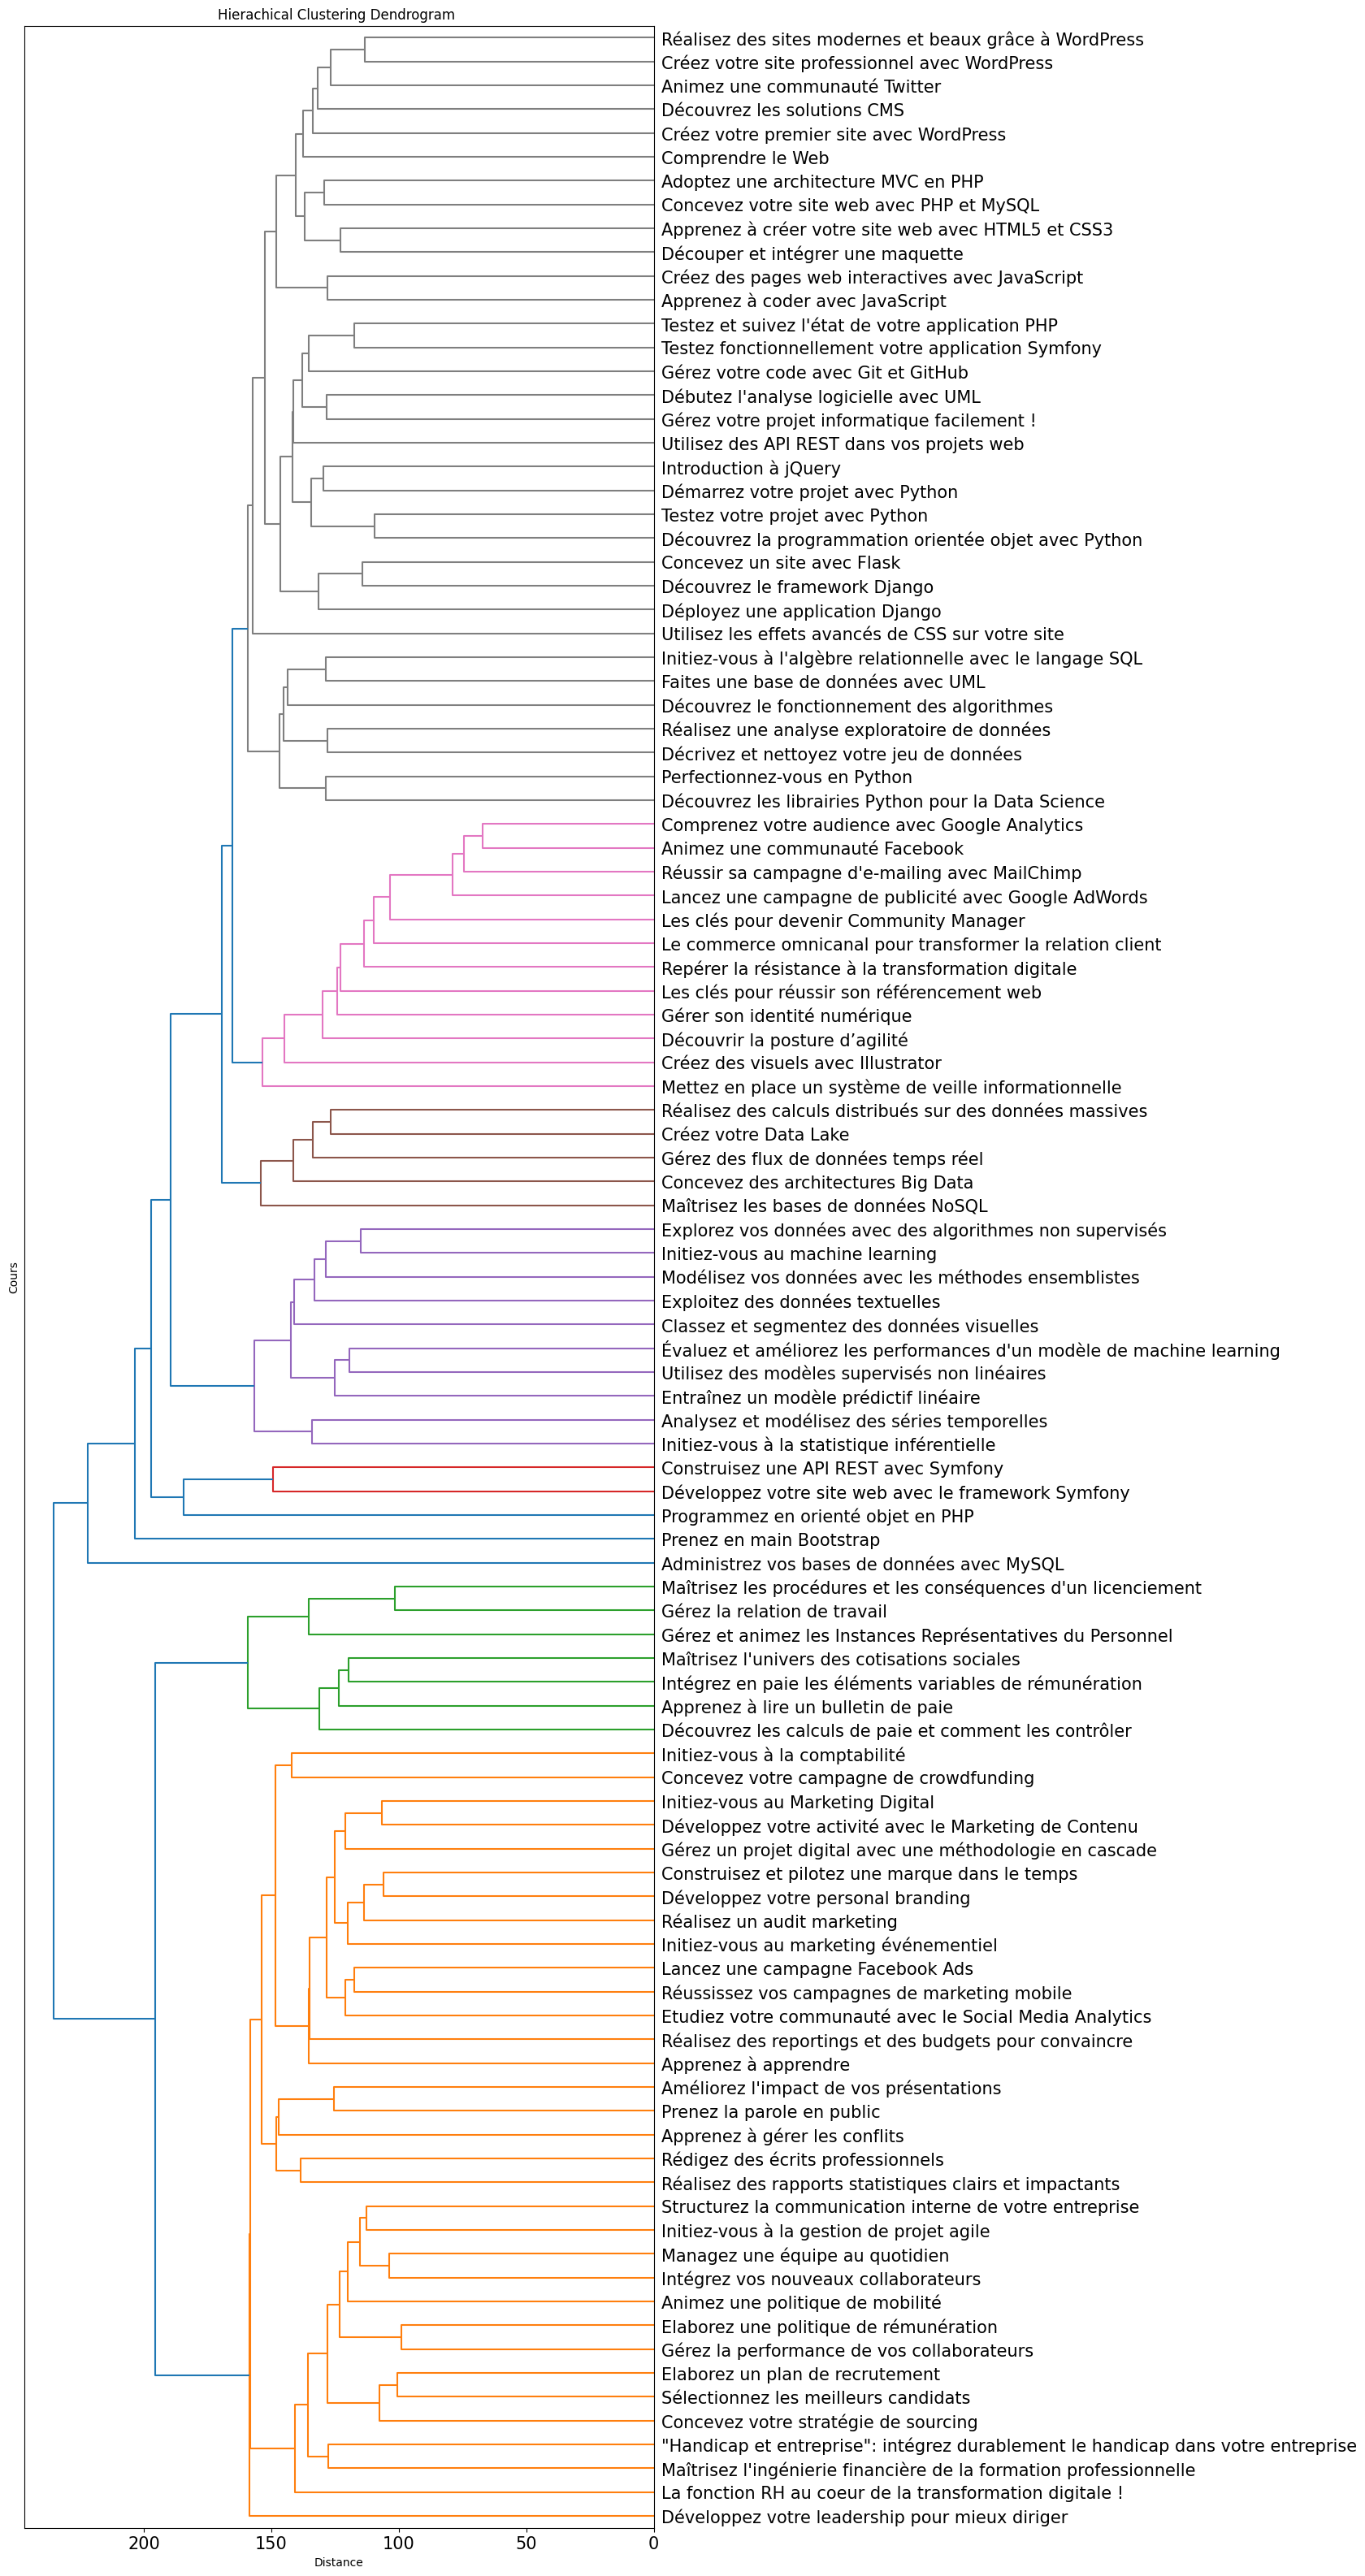

In [33]:
# Graphique du dendrogramme

# Initialisation du graphique et de l'axe
fig,ax = plt.subplots(1,1,figsize=(10,40))

# dendrogramme
_ = dendrogram(Z,ax=ax,labels=names,orientation="left")

# paramètres
plt.title("Hierachical Clustering Dendrogram ")
ax.set_xlabel("Distance")
ax.set_ylabel("Cours")
ax.tick_params(axis='x',which='major',labelsize=15)
ax.tick_params(axis="y", which="major", labelsize=15)

plt.show()



### 3.3 Clusters
On récupère nos clusters

In [34]:
# On définit le nombre de clusters qu'on souhaite avoir
k = 12

In [35]:
# On recupère nos k clusters
clusters = fcluster(Z,k,criterion='maxclust')
clusters[:5]

array([ 7, 10, 10,  8,  6], dtype=int32)

### 3.4 Analyse
Nous allons analyser la pertinence de notre clustering avec un tableau de contingence.

In [36]:
# creation du tableau de contingence
crosstab = pd.crosstab(themes,clusters,dropna=False)

crosstab.rename_axis(columns='cluster',index='theme',inplace=True)

crosstab

cluster,1,2,3,4,5,6,7,8,9,10,11,12
theme,,,,,,,,,,,,
RH,14,4,3,0,0,0,0,2,0,0,0,0
RH & marketing,6,0,0,0,0,0,0,3,0,1,0,0
data,1,0,0,0,0,10,5,0,4,0,0,0
dev,0,0,0,2,1,0,0,0,3,18,1,1
marketing,10,0,0,0,0,0,0,6,0,2,0,0
multi-parcours,2,0,0,0,0,0,0,1,0,5,0,0


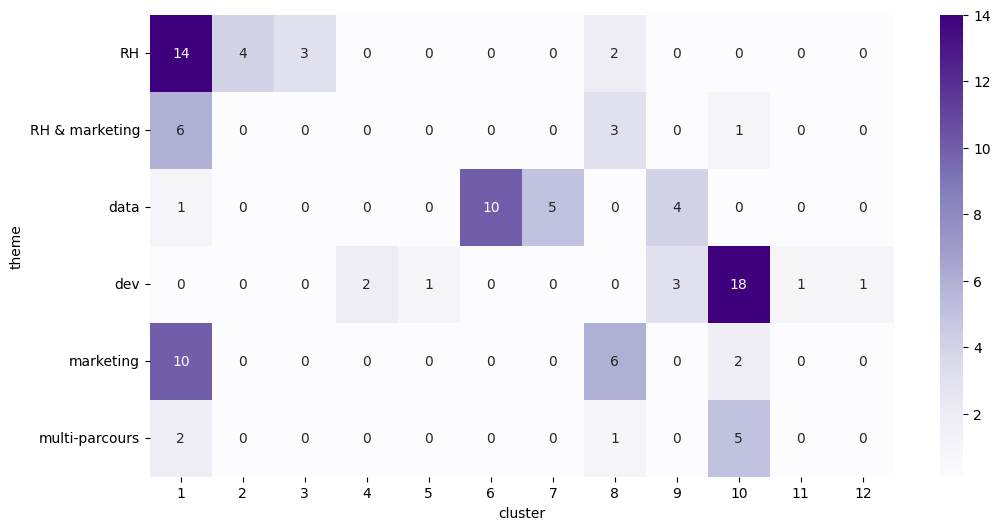

In [37]:
# Graphique du tableau de contingence
fig,ax = plt.subplots(1,1,figsize=(12,6))
ax = sns.heatmap(crosstab,vmin=0.1,vmax=14,annot=True,cmap="Purples")

Affichons un dataframe avec les cours et leurs clusters

In [39]:
df=pd.DataFrame({'name':names,'cluster':clusters,'theme':themes})
df.head()

,name,cluster,theme
0,Concevez des architectures Big Data,7,data
1,Apprenez à coder avec JavaScript,10,dev
2,Concevez votre site web avec PHP et MySQL,10,dev
3,Réussir sa campagne d'e-mailing avec MailChimp,8,marketing
4,Utilisez des modèles supervisés non linéaires,6,data


In [40]:
for i in range(1, 13):
    # on fait une selection
    sub_df = df.loc[df.cluster == i]

    # le cluster en question
    print(f"cluster : {i}")

    # on extrait les noms et les themes de chaque ligne
    names_list = sub_df.name.values
    themes_list = sub_df.theme.values

    # on créé une liste de couple nom/theme
    ziped = zip(names_list, themes_list)
    txt = [f"{n} ({t})" for n, t in ziped]

    # on transforme en str
    txt = " / ".join(txt)

    # on print
    print(txt)
    print("\n\n")

cluster : 1
Apprenez à apprendre (multi-parcours) / Initiez-vous à la gestion de projet agile (RH & marketing) / Réussissez vos campagnes de marketing mobile (marketing) / Gérez un projet digital avec une méthodologie en cascade (multi-parcours) / Développez votre activité avec le Marketing de Contenu (marketing) / Intégrez vos nouveaux collaborateurs (RH) / Maîtrisez l'ingénierie financière de la formation professionnelle (RH) / Initiez-vous au Marketing Digital (marketing) / Sélectionnez les meilleurs candidats (RH) / Réalisez des reportings et des budgets pour convaincre (RH) / Gérez la performance de vos collaborateurs (RH) / Apprenez à gérer les conflits (RH) / Développez votre leadership pour mieux diriger (RH & marketing) / Structurez la communication interne de votre entreprise (RH & marketing) / Prenez la parole en public (RH & marketing) / Initiez-vous au marketing événementiel (marketing) / Concevez votre stratégie de sourcing (RH) / "Handicap et entreprise": intégrez durabl